In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv("sleep_disorder_balanced_realistic_11600.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11600, 5)


,hr,motion,spo2,sleep_time,disorder
0,81.92,29.64,96.23,5.92,Insomnia
1,98.85,41.92,96.52,6.18,Sleep Walking
2,75.42,57.45,100.00,8.39,Sleep Walking
3,94.44,36.45,95.96,5.69,Insomnia
4,65.04,11.11,99.71,6.97,Normal


disorder
Sleep Apnea      3100
Normal           3000
Sleep Walking    2800
Insomnia         2700
Name: count, dtype: int64


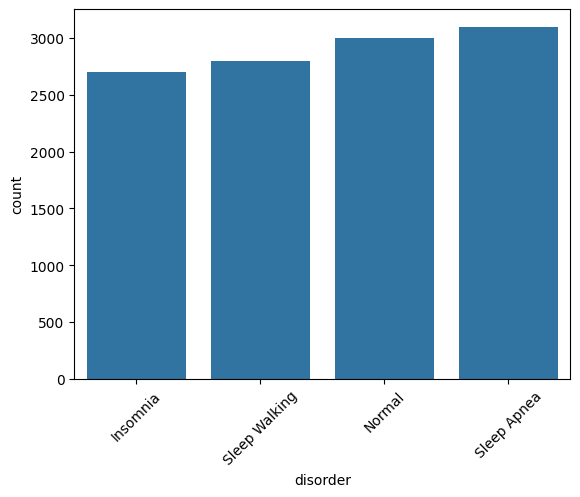

In [6]:
print(df['disorder'].value_counts())

sns.countplot(x='disorder', data=df)
plt.xticks(rotation=45)
plt.show()

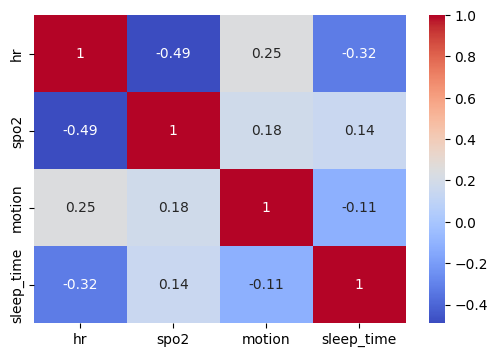

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['hr','spo2','motion','sleep_time']].corr(),
            annot=True, cmap='coolwarm')
plt.show()

In [8]:
le = LabelEncoder()
df['disorder_encoded'] = le.fit_transform(df['disorder'])

X = df[['hr','spo2','motion','sleep_time']]
y = df['disorder_encoded']

print("Classes:", le.classes_)

Classes: ['Insomnia' 'Normal' 'Sleep Apnea' 'Sleep Walking']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9543
KNN: 0.9461
SVM: 0.9552
Random Forest: 0.9573


In [12]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Random Forest


In [13]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

joblib.dump(best_model, "sleep_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


<Figure size 800x600 with 0 Axes>

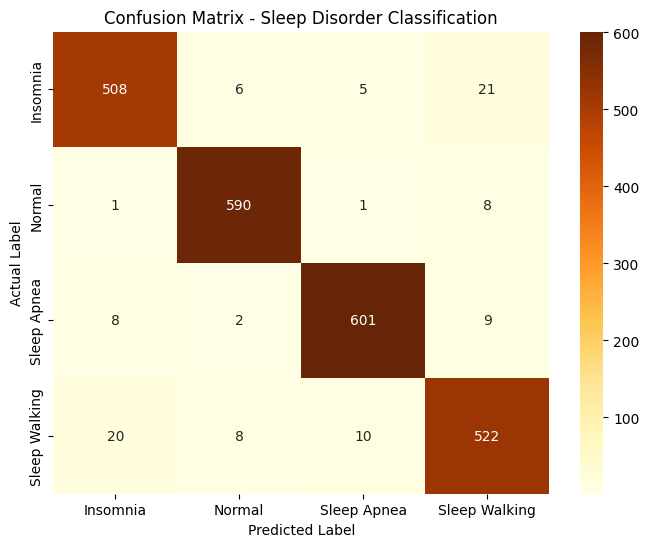

: 

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Load model and encoder
model = joblib.load("sleep_model.pkl")
le = joblib.load("label_encoder.pkl")

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='YlOrBr',   # Yellow-Orange-Brown
            xticklabels=le.classes_,
            yticklabels=le.classes_)


plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Sleep Disorder Classification")
plt.show()

Model Saved Successfully


Predicted: Sleep Walking
